In [1]:
# World Population Analysis

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter
import os

"""
The global population trends explored in this notebook are:
1. Weighted population growth rate by continent.
2. Relationship between growth rate and population size.
3. How much each continent contributes to the world population.
All three are illustrated using matplotlib.
"""

In [7]:
os.chdir("C:\\Users\\Owner\\Downloads")
df = pd.read_csv("world_population.csv")
""" 
Changing the index of each country to its corresponding continent.
This is done to create a separate dataframe for each continent.
"""
indexes = df["Continent"].tolist()
df.index = indexes
counted_continents = dict(Counter(indexes))
continental_dataframes = {} # dictionary containing continents (as keys) and their individual dataframes (as values).

for continent in counted_continents.keys():
    new_df = pd.DataFrame(df.loc[f"{continent}"])
    continental_dataframes.setdefault(f"{continent}".title(), new_df)

"""" 
Create a new column in each continent dataframe for the weights of each of the countries in the dataframe as a percentage.
"""
continental_growth_rate = {}
for continent in continental_dataframes.keys():
    weights = np.array(continental_dataframes[continent]["2022 Population"]/
                        continental_dataframes[continent]["2022 Population"].sum())
    continental_dataframes[continent]["Weights"] = weights
    continental_growth_rate.setdefault(continent, 0)
    continental_growth_rate[continent] = float((np.array(weights *
                                                continental_dataframes[continent]["Growth Rate"].values)).sum())

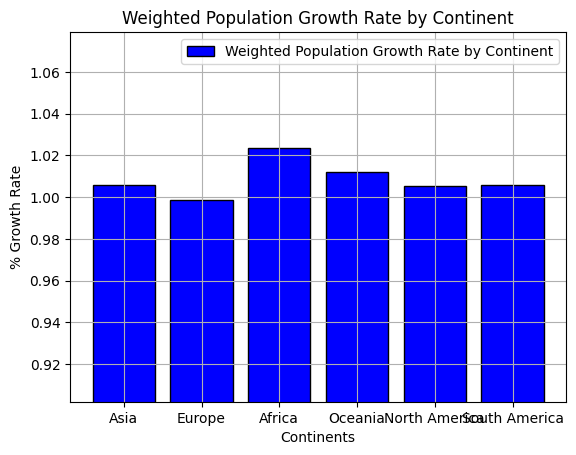

In [13]:
max_g = float(np.max(df["Growth Rate"])) + 0.01
min_g = float(np.min(df["Growth Rate"])) - 0.01
max_pop = float(np.max(df["2022 Population"])) + 100000000
min_pop = float(np.min(df["2022 Population"])) - 100
plt.bar(list(counted_continents.keys()), list(continental_growth_rate.values()),
         color="blue", edgecolor="black", label="Weighted Population Growth Rate by Continent")
plt.xlabel("Continents")
plt.ylabel("% Growth Rate")
plt.title("Weighted Population Growth Rate by Continent")
plt.ylim(min_g, max_g)
plt.legend()
plt.grid(True)
plt.savefig(fname="weighted_continental_population_growth_rate.png")
plt.show()

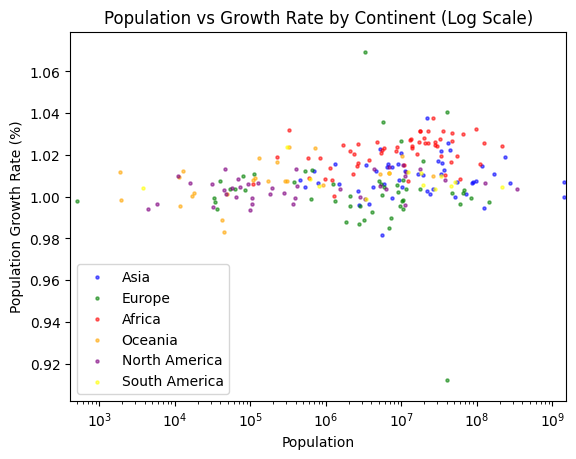

In [18]:
""" 
Create a scatter plot for all the countries showing their growth percentage.
Each continent should have a different color for their countries.
"""

colors = {"Asia":"blue", "Africa":"red", "Oceania":"orange", "Europe":"green",
          "South America":"yellow", "North America":"purple"}

fig, ax = plt.subplots()

for continent in continental_dataframes.keys():
    continent_name = continental_dataframes[continent]
    x, y, z = continent_name["2022 Population"], continent_name["Growth Rate"], continent_name["Country/Territory"]
    ax.scatter(x, y, s=5, color=colors[continent], label=f"{continent}", alpha=0.55)

ax.set_xscale('log') # using log scale on x (population) axis for visual clarity because many countries overlap
ax.set(xlabel="Population", ylabel="Population Growth Rate (%)",
       title="Population vs Growth Rate by Continent (Log Scale)")
ax.axis([min_pop, max_pop, min_g, max_g])
ax.legend(loc="lower left")
plt.show()

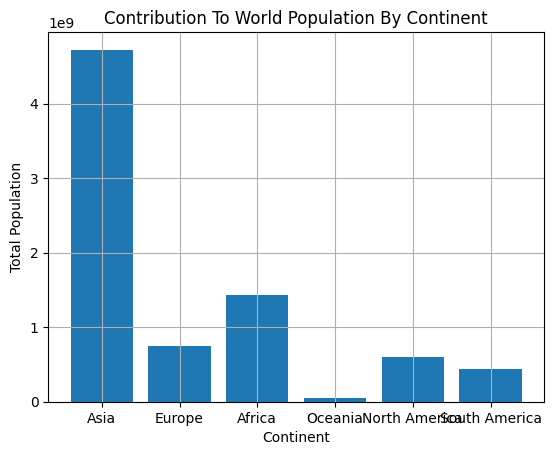

In [15]:
"""
Bar chart of Contribution of each continent to the global population.
Calculate sum of each continent's population and that will form the Y-axis.
"""

total_population = np.array([continental_dataframes[continent]["2022 Population"].sum()
                             for continent in continental_dataframes.keys()])

plt.bar(continental_dataframes.keys(), total_population)
plt.xlabel("Continent")
plt.ylabel("Total Population")
plt.title("Contribution To World Population By Continent")
plt.grid(True)
plt.plot()
plt.show()